# Getting the caption of the input image

reshape position embedding from 196 to 1024
load checkpoint from https://storage.googleapis.com/sfr-vision-language-research/BLIP/models/model_base_capfilt_large.pth
caption:a gnome with a red hat


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.


  0%|          | 0/90 [00:00<?, ?it/s]

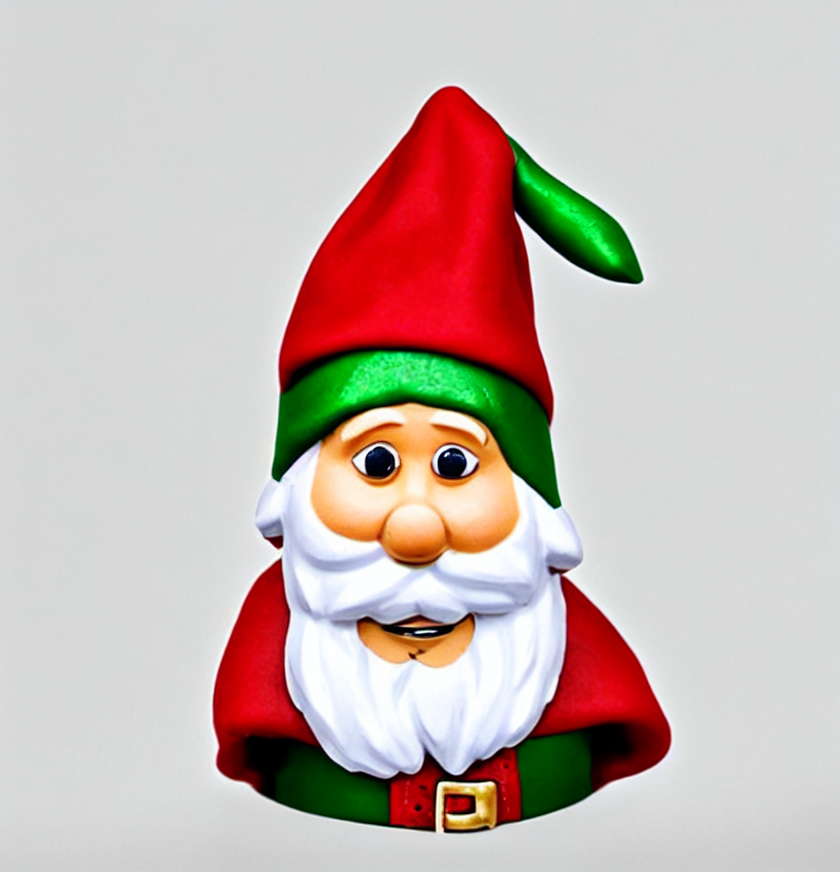

: 

In [4]:
from PIL import Image
import requests
import torch
from torchvision import transforms
from torchvision.transforms.functional import InterpolationMode
import logging
from pathlib import Path
from diffusers import StableDiffusionPipeline
from fastcore.all import concat
from diffusers import StableDiffusionImg2ImgPipeline
import os

SDV5_MODEL_PATH = r'C:\Users\enesm\stable-diffusion-v1-5'


device = torch.device('cpu')
path= r"C:\Users\enesm\OneDrive\Masaüstü\IMAGES\image-219090.png"
raw_image = Image.open(path).convert('RGB')

def load_demo_image(image_size,device,image):
    w,h = raw_image.size    
    transform = transforms.Compose([
        transforms.Resize((image_size,image_size),interpolation=InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711))
        ]) 
    image = transform(raw_image).unsqueeze(0).to(device)   
    return image


from models.blip import blip_decoder

image_size = 512
image = load_demo_image(image_size=image_size, device=device,image=raw_image)

model_url = 'https://storage.googleapis.com/sfr-vision-language-research/BLIP/models/model_base_capfilt_large.pth'
model = blip_decoder(pretrained=model_url, image_size=image_size, vit='base')
model.eval()
model = model.to(device)

with torch.no_grad():
    # beam search
    caption = model.generate(image, sample=False, num_beams=1, max_length=20, min_length=10) 
    # nucleus sampling
    # caption = model.generate(image, sample=True, top_p=0.9, max_length=20, min_length=5) 
    print('caption:'+caption[0])
model.to('cpu')

torch.cuda.empty_cache()

def image_grid(imgs,rows,cols):
    w,h = imgs[0].size
    grid = Image.new('RGB', size = (cols*w , rows*h))
    for i, img in enumerate(imgs): grid.paste(img,box=(i%cols*w, i//cols*h))
    return grid



pipe = StableDiffusionImg2ImgPipeline.from_pretrained(SDV5_MODEL_PATH, revision="fp16", torch_dtype=torch.float16).to("cuda")
caption = caption[0]
hex_code="#e4b7ff"
prompt=(f" {caption} Please incorporate the green colour within the hat ")
negative_prompt="without hex code colour added "

images = pipe(prompt=prompt, num_images_per_prompt=1, image=raw_image, strength=0.9, num_inference_steps=100,negative_prompt=negative_prompt,guidance_scale=15).images
image_grid(images, rows=1, cols=1)


In [2]:
prompt

' a gnome with a red hat Please incorporate the hex color #e4b7ff within the hat '